# 09 - Ring-based spillover estimation

This notebook estimates final ring-based spillover diagnostics using untreated cells. It reports HT and Hajek contrasts by year and ring, relative to cells farther than the reference distance from treated cells.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.estimation_workflow_utils import append_tag_to_filename, ht_hajek_ring_diagnostics, hac_for_hajek_ring_contrasts

DATA_DIR = PROJECT_ROOT / 'data'
INTERMEDIATE_DIR = DATA_DIR / 'intermediate'
SPATIAL_DIR = INTERMEDIATE_DIR / 'spatial_structure'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'
for path in [TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)


Project root: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2


## User configuration

In [4]:
RUN_TAG = '1km'
START_YEAR = 2001
END_YEAR = None
TREATMENT_KEY = 'protected_area'
CELL_COL = 'cell_id'
YEAR_COL = 'year'
OUTCOME_COL = 'loss_m2'
REFERENCE_DISTANCE_KM = 50

PANEL_PATH = INTERMEDIATE_DIR / f'panel_treatment_{RUN_TAG}.parquet'
if not PANEL_PATH.exists():
    PANEL_PATH = INTERMEDIATE_DIR / 'panel_treatment.parquet'
EXPOSURE_PATH = INTERMEDIATE_DIR / append_tag_to_filename('06_nearest_treated_exposure.parquet', RUN_TAG)
CENTROID_PATH = SPATIAL_DIR / append_tag_to_filename('03_grid_centroids.parquet', RUN_TAG)
if not CENTROID_PATH.exists():
    CENTROID_PATH = SPATIAL_DIR / '03_grid_centroids.parquet'

SPILLOVER_TABLE_NAME = '09_ring_spillover_ht_hajek.csv'
SPILLOVER_EVENT_TABLE_NAME = '09_ring_spillover_event_time.csv'
SPILLOVER_HAC_TABLE_NAME = '09_ring_spillover_spatial_hac.csv'
STAGGERED_SPILLOVER_ATTGT_NAME = '09_staggered_spillover_attgt.csv'
STAGGERED_SPILLOVER_EVENT_NAME = '09_staggered_spillover_event_time.csv'
STAGGERED_SPILLOVER_OVERALL_NAME = '09_staggered_spillover_overall.csv'
HAC_CUTOFF_KM = 25
HAC_KERNEL = 'bartlett'
HAC_MAX_PAIRS = 50_000_000
SPILLOVER_EVENT_WINDOW_MIN = -8
SPILLOVER_EVENT_WINDOW_MAX = 8
SPILLOVER_FIG_NAME = '09_ring_spillover_profiles.png'
STAGGERED_SPILLOVER_FIG_NAME = '09_staggered_spillover_event_study.png'


## Load untreated outcome cells and exposure rings

In [5]:
treated_col = f'treated_it_{TREATMENT_KEY}'
panel_cols = [CELL_COL, YEAR_COL, OUTCOME_COL, treated_col, 'first_treat_year', 'event_time']
try:
    panel = pd.read_parquet(PANEL_PATH, columns=panel_cols)
except Exception:
    treated_col = 'treated_it'
    panel_cols = [CELL_COL, YEAR_COL, OUTCOME_COL, treated_col, 'first_treat_year', 'event_time']
    panel = pd.read_parquet(PANEL_PATH, columns=panel_cols)
panel[CELL_COL] = panel[CELL_COL].astype('string')
panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors='coerce').astype(int)
panel = panel[panel[YEAR_COL] >= START_YEAR].copy()
if END_YEAR is not None:
    panel = panel[panel[YEAR_COL] <= END_YEAR].copy()

exposure = pd.read_parquet(EXPOSURE_PATH)
exposure[CELL_COL] = exposure[CELL_COL].astype('string')
exposure[YEAR_COL] = pd.to_numeric(exposure[YEAR_COL], errors='coerce').astype(int)
centroids = pd.read_parquet(CENTROID_PATH)
centroids[CELL_COL] = centroids[CELL_COL].astype('string')

df = panel.merge(exposure[[CELL_COL, YEAR_COL, 'nearest_treated_distance_km', 'distance_ring']], on=[CELL_COL, YEAR_COL], how='left')
df = df[pd.to_numeric(df[treated_col], errors='coerce').fillna(0).astype(int) == 0].copy()
df['spillover_ring'] = df['distance_ring'].astype('string')
df.loc[df['nearest_treated_distance_km'] > REFERENCE_DISTANCE_KM, 'spillover_ring'] = f'gt_{REFERENCE_DISTANCE_KM}km'
reference_label = f'gt_{REFERENCE_DISTANCE_KM}km'
df = df.dropna(subset=['spillover_ring'])
print('Untreated rows:', f'{len(df):,}')
print(df['spillover_ring'].value_counts().to_string())


Untreated rows: 24,723,878
spillover_ring
gt_50km    7592069
25_50km    6157190
10_25km    6054564
0_5km      2474708
5_10km     2445347


## HT and Hajek ring contrasts

In [6]:
spillover = ht_hajek_ring_diagnostics(
    df,
    outcome_col=OUTCOME_COL,
    year_col=YEAR_COL,
    ring_col='spillover_ring',
    reference_label=reference_label,
)
spillover_path = TABLE_DIR / append_tag_to_filename(SPILLOVER_TABLE_NAME, RUN_TAG)
spillover.to_csv(spillover_path, index=False)
print('Saved:', spillover_path)
print(spillover.head(12).to_string(index=False))


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\09_ring_spillover_ht_hajek_1km.csv
 year    ring reference_ring  n_ring  n_reference  exposure_probability  reference_probability  ht_difference  hajek_difference
 2001   0_5km        gt_50km   57928       484014              0.055852               0.466671     247.900850        247.900850
 2001 10_25km        gt_50km  179788       484014              0.173346               0.466671     176.157880        176.157880
 2001 25_50km        gt_50km  254742       484014              0.245614               0.466671     214.235704        214.235704
 2001  5_10km        gt_50km   60691       484014              0.058516               0.466671     218.161920        218.161920
 2002   0_5km        gt_50km   60603       466213              0.059075               0.454457    -103.895688       -103.895688
 2002 10_25km        gt_50km  183660       466213              0.179029               0.454457     -69.454186       

## Spatial HAC for Hajek ring contrasts

In [ ]:
spillover_hac = hac_for_hajek_ring_contrasts(
    df,
    centroids,
    cell_col=CELL_COL,
    year_col=YEAR_COL,
    outcome_col=OUTCOME_COL,
    ring_col='spillover_ring',
    reference_label=reference_label,
    cutoff_km=HAC_CUTOFF_KM,
    kernel=HAC_KERNEL,
    max_pairs=HAC_MAX_PAIRS,
)
spillover_hac_path = TABLE_DIR / append_tag_to_filename(SPILLOVER_HAC_TABLE_NAME, RUN_TAG)
spillover_hac.to_csv(spillover_hac_path, index=False)
print('Saved:', spillover_hac_path)
print(spillover_hac.head(12).to_string(index=False))
if not spillover_hac.empty and spillover_hac['hac_truncated'].any():
    print('Warning: at least one HAC calculation hit HAC_MAX_PAIRS. Increase HAC_MAX_PAIRS or reduce HAC_CUTOFF_KM after checking runtime/memory.')


## Event-time version

This version summarizes rings around the nearest treated cell by calendar year. It is not cohort-specific unless a nearest-treated-cohort lookup is added later.

In [ ]:
event_summary = (
    spillover.groupby('ring')
    .agg(
        mean_ht_difference=('ht_difference', 'mean'),
        mean_hajek_difference=('hajek_difference', 'mean'),
        p25_hajek_difference=('hajek_difference', lambda x: x.quantile(0.25)),
        p75_hajek_difference=('hajek_difference', lambda x: x.quantile(0.75)),
        n_years=('year', 'nunique'),
        mean_n_ring=('n_ring', 'mean'),
    )
    .reset_index()
)
event_path = TABLE_DIR / append_tag_to_filename(SPILLOVER_EVENT_TABLE_NAME, RUN_TAG)
event_summary.to_csv(event_path, index=False)
print('Saved:', event_path)
print(event_summary.to_string(index=False))


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\09_ring_spillover_event_time_1km.csv
   ring  mean_ht_difference  mean_hajek_difference  p25_hajek_difference  p75_hajek_difference  n_years  mean_n_ring
  0_5km           35.511021              35.511021           -171.722264            268.360211       25     98988.32
10_25km          220.527998             220.527998            -69.454186            390.954192       25    242182.56
25_50km          227.846979             227.846979            -17.127802            413.993726       25    246287.60
 5_10km           97.550490              97.550490           -133.711662            380.252894       25     97813.88


## Staggered-DiD spillover estimate

This section treats untreated neighboring cells as spillover-exposed units. For each directly treated cohort `g`, it compares outcome changes for untreated cells in each distance ring around cohort `g` with outcome changes for clean far untreated cells. The baseline is `g - 1`, so event time is `t - g`.

In [ ]:
def cohort_distance_exposure(cohort_cells, centroids, *, cell_col, rings_km, reference_distance_km):
    cohort_cells = cohort_cells.astype('string').dropna().drop_duplicates()
    coords_df = centroids[[cell_col, 'centroid_x_m', 'centroid_y_m']].drop_duplicates(cell_col).copy()
    coords_df[cell_col] = coords_df[cell_col].astype('string')
    treated_coords = coords_df.loc[coords_df[cell_col].isin(cohort_cells), ['centroid_x_m', 'centroid_y_m']].to_numpy(dtype=float)
    if treated_coords.size == 0:
        return pd.DataFrame(columns=[cell_col, 'cohort_distance_km', 'cohort_ring'])
    all_coords = coords_df[['centroid_x_m', 'centroid_y_m']].to_numpy(dtype=float)
    nearest_m, _ = cKDTree(treated_coords).query(all_coords, k=1)
    out = coords_df[[cell_col]].copy()
    out['cohort_distance_km'] = nearest_m / 1000.0
    out['cohort_ring'] = pd.Series(pd.NA, index=out.index, dtype='string')
    for inner, outer in rings_km:
        label = f'{inner:g}_{outer:g}km'
        out.loc[(out['cohort_distance_km'] > float(inner)) & (out['cohort_distance_km'] <= float(outer)), 'cohort_ring'] = label
    out.loc[out['cohort_distance_km'] > float(reference_distance_km), 'cohort_ring'] = f'gt_{reference_distance_km:g}km'
    return out.dropna(subset=['cohort_ring'])


def diff_in_diff_for_ring(cohort_df, *, cell_col, year_col, outcome_col, ring_label, reference_label, base_year, time_year):
    use = cohort_df.loc[cohort_df[year_col].isin([base_year, time_year]), [cell_col, year_col, outcome_col, 'cohort_ring', 'spillover_ring']].copy()
    if use.empty:
        return None
    clean_reference_ids = set(use.loc[(use[year_col] == time_year) & (use['spillover_ring'].astype('string') == reference_label), cell_col])
    wide = (
        use.pivot_table(index=[cell_col, 'cohort_ring'], columns=year_col, values=outcome_col, aggfunc='mean')
        .reset_index()
        .dropna(subset=[base_year, time_year])
    )
    if wide.empty:
        return None
    wide['delta_y'] = wide[time_year] - wide[base_year]
    exposed = wide.loc[wide['cohort_ring'].astype('string') == ring_label, 'delta_y']
    reference = wide.loc[(wide['cohort_ring'].astype('string') == reference_label) & wide[cell_col].isin(clean_reference_ids), 'delta_y']
    n_exposed = int(exposed.notna().sum())
    n_reference = int(reference.notna().sum())
    if n_exposed == 0 or n_reference == 0:
        return None
    att = float(exposed.mean() - reference.mean())
    se = float(np.sqrt(exposed.var(ddof=1) / n_exposed + reference.var(ddof=1) / n_reference)) if n_exposed > 1 and n_reference > 1 else np.nan
    return {'att': att, 'se': se, 'n_exposed': n_exposed, 'n_reference': n_reference, 'exposed_delta_mean': float(exposed.mean()), 'reference_delta_mean': float(reference.mean())}


RINGS_KM = [(0, 5), (5, 10), (10, 25), (25, 50)]
ring_labels = [f'{inner:g}_{outer:g}km' for inner, outer in RINGS_KM]
reference_label = f'gt_{REFERENCE_DISTANCE_KM:g}km'
cell_timing = panel[[CELL_COL, 'first_treat_year']].drop_duplicates(CELL_COL).copy()
valid_cohorts = sorted(int(g) for g in cell_timing['first_treat_year'].dropna().unique() if int(g) > START_YEAR)
available_years = sorted(int(y) for y in df[YEAR_COL].unique())

attgt_rows = []
for cohort_year in valid_cohorts:
    base_year = cohort_year - 1
    if base_year not in available_years:
        continue
    cohort_cells = cell_timing.loc[cell_timing['first_treat_year'] == cohort_year, CELL_COL]
    cohort_exposure = cohort_distance_exposure(cohort_cells, centroids, cell_col=CELL_COL, rings_km=RINGS_KM, reference_distance_km=REFERENCE_DISTANCE_KM)
    cohort_df = df.merge(cohort_exposure, on=CELL_COL, how='inner')
    for event_time in range(SPILLOVER_EVENT_WINDOW_MIN, SPILLOVER_EVENT_WINDOW_MAX + 1):
        time_year = cohort_year + event_time
        if time_year not in available_years:
            continue
        for ring_label in ring_labels:
            estimate = diff_in_diff_for_ring(cohort_df, cell_col=CELL_COL, year_col=YEAR_COL, outcome_col=OUTCOME_COL, ring_label=ring_label, reference_label=reference_label, base_year=base_year, time_year=time_year)
            if estimate is None:
                continue
            attgt_rows.append({'cohort_year': cohort_year, 'year': time_year, 'event_time': event_time, 'ring': ring_label, 'reference_ring': reference_label, **estimate})

staggered_spillover_attgt = pd.DataFrame(attgt_rows)
attgt_path = TABLE_DIR / append_tag_to_filename(STAGGERED_SPILLOVER_ATTGT_NAME, RUN_TAG)
staggered_spillover_attgt.to_csv(attgt_path, index=False)
print('Saved:', attgt_path)
print(staggered_spillover_attgt.head(12).to_string(index=False) if not staggered_spillover_attgt.empty else 'No staggered spillover estimates created.')


In [ ]:
if not staggered_spillover_attgt.empty:
    staggered_spillover_attgt['event_time_plot'] = staggered_spillover_attgt['event_time'] + 1
    staggered_spillover_event = staggered_spillover_attgt.groupby(['ring', 'event_time'], as_index=False).agg(att=('att', 'mean'), se=('att', lambda values: values.std(ddof=1) / np.sqrt(values.notna().sum()) if values.notna().sum() > 1 else np.nan), n_cohort_years=('att', 'count'), mean_n_exposed=('n_exposed', 'mean'), mean_n_reference=('n_reference', 'mean'))
    staggered_spillover_event['event_time_plot'] = staggered_spillover_event['event_time'] + 1
    staggered_spillover_event['ci_low'] = staggered_spillover_event['att'] - 1.96 * staggered_spillover_event['se']
    staggered_spillover_event['ci_high'] = staggered_spillover_event['att'] + 1.96 * staggered_spillover_event['se']
    staggered_spillover_overall = staggered_spillover_attgt.loc[staggered_spillover_attgt['event_time'] >= 0].groupby('ring', as_index=False).agg(att=('att', 'mean'), se=('att', lambda values: values.std(ddof=1) / np.sqrt(values.notna().sum()) if values.notna().sum() > 1 else np.nan), n_cohort_years=('att', 'count'), mean_n_exposed=('n_exposed', 'mean'), mean_n_reference=('n_reference', 'mean'))
    staggered_spillover_overall['ci_low'] = staggered_spillover_overall['att'] - 1.96 * staggered_spillover_overall['se']
    staggered_spillover_overall['ci_high'] = staggered_spillover_overall['att'] + 1.96 * staggered_spillover_overall['se']
else:
    staggered_spillover_event = pd.DataFrame()
    staggered_spillover_overall = pd.DataFrame()

event_did_path = TABLE_DIR / append_tag_to_filename(STAGGERED_SPILLOVER_EVENT_NAME, RUN_TAG)
overall_did_path = TABLE_DIR / append_tag_to_filename(STAGGERED_SPILLOVER_OVERALL_NAME, RUN_TAG)
staggered_spillover_event.to_csv(event_did_path, index=False)
staggered_spillover_overall.to_csv(overall_did_path, index=False)
print('Saved:', event_did_path)
print(staggered_spillover_event.head(12).to_string(index=False) if not staggered_spillover_event.empty else 'No staggered spillover event-time summary created.')
print('Saved:', overall_did_path)
print(staggered_spillover_overall.to_string(index=False) if not staggered_spillover_overall.empty else 'No staggered spillover overall summary created.')


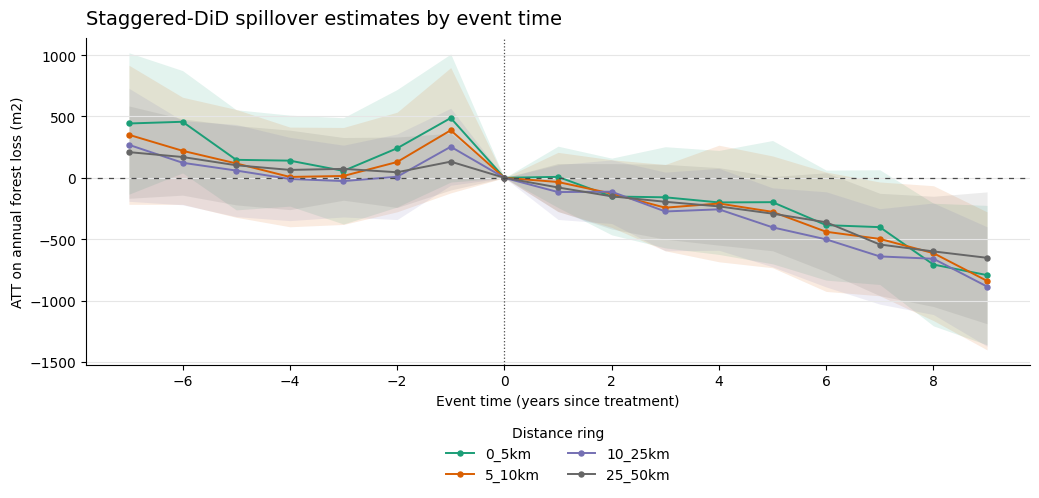

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\09_staggered_spillover_event_study_1km.png


In [23]:
staggered_fig_path = FIG_DIR / append_tag_to_filename(STAGGERED_SPILLOVER_FIG_NAME, RUN_TAG)
if not staggered_spillover_event.empty:
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    colors = {'0_5km': '#1b9e77', '5_10km': '#d95f02', '10_25km': '#7570b3', '25_50km': '#666666'}
    for ring_label in ring_labels:
        sub = staggered_spillover_event.loc[staggered_spillover_event['ring'] == ring_label].sort_values('event_time')
        if sub.empty:
            continue
        plot_event_time = sub['event_time'] + 1
        ax.plot(plot_event_time, sub['att'], marker='o', markersize=3.6, linewidth=1.4, color=colors.get(ring_label), label=ring_label)
        if sub['se'].notna().any():
            ax.fill_between(plot_event_time, sub['ci_low'], sub['ci_high'], color=colors.get(ring_label), alpha=0.12, linewidth=0)
    ax.axhline(0, color='#4a4a4a', linewidth=0.9, linestyle=(0, (4, 5)))
    ax.axvline(0, color='#4a4a4a', linewidth=0.9, linestyle=':')
    ax.set_title('Staggered-DiD spillover estimates by event time', loc='left', fontsize=14, pad=10)
    ax.set_xlabel('Event time (years since treatment)')
    ax.set_ylabel('ATT on annual forest loss (m2)')
    ax.grid(True, axis='y', color='#e6e6e6', linewidth=0.8)
    ax.grid(False, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='Distance ring', frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    fig.tight_layout()
    fig.savefig(staggered_fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', staggered_fig_path)
else:
    print('Staggered-DiD spillover figure skipped because no estimates were created.')


## Descriptive spillover mean-difference diagnostic

This figure is not a staggered-DiD effect estimate. It plots average differences in forest loss by distance from currently treated cells relative to cells farther than the reference distance.

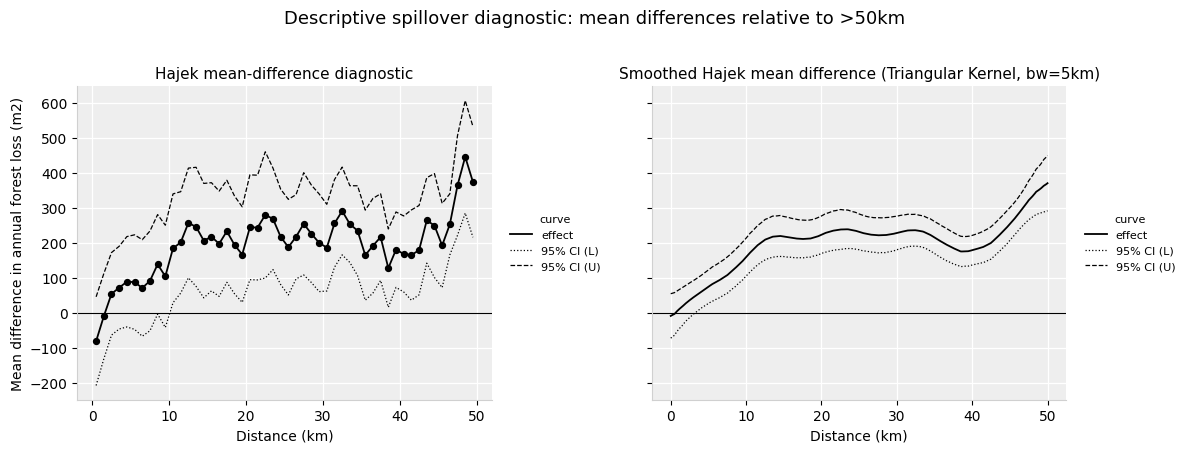

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\09_ring_spillover_profiles_1km.png
Figure note: profile intervals are empirical 95% intervals across annual 1km-bin contrasts; ring-level spatial HAC estimates remain in the HAC table.
Spatial HAC note: Hajek ring-contrast HAC estimates are saved in the dedicated HAC table. Full all-pairs matrices are never materialized; the KDTree routine stops if HAC_MAX_PAIRS is reached.


In [19]:
def ring_bounds_km(ring_label):
    cleaned = str(ring_label).replace('km', '')
    low, high = cleaned.split('_')[:2]
    return float(low), float(high)


def triangular_smooth(x, y, grid, bandwidth):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    weights = np.maximum(1.0 - np.abs(grid[:, None] - x[None, :]) / bandwidth, 0.0)
    denom = weights.sum(axis=1)
    return np.divide(weights @ y, denom, out=np.full_like(grid, np.nan, dtype=float), where=denom > 0)


def triangular_smooth_se(x, se, grid, bandwidth):
    x = np.asarray(x, dtype=float)
    se = np.asarray(se, dtype=float)
    weights = np.maximum(1.0 - np.abs(grid[:, None] - x[None, :]) / bandwidth, 0.0)
    denom = weights.sum(axis=1)
    variance = (weights ** 2) @ (se ** 2)
    return np.divide(np.sqrt(variance), denom, out=np.full_like(grid, np.nan, dtype=float), where=denom > 0)


fig_path = FIG_DIR / append_tag_to_filename(SPILLOVER_FIG_NAME, RUN_TAG)
SMOOTH_BW_KM = 5.0
DISTANCE_BIN_WIDTH_KM = 1.0
MAX_PROFILE_DISTANCE_KM = min(float(REFERENCE_DISTANCE_KM), 50.0)

if not spillover.empty:
    reference_label = f'gt_{REFERENCE_DISTANCE_KM:g}km'
    if 'df' in globals() and {'nearest_treated_distance_km', 'spillover_ring', YEAR_COL, OUTCOME_COL}.issubset(df.columns):
        reference_means = (
            df.loc[df['spillover_ring'].astype('string') == reference_label, [YEAR_COL, OUTCOME_COL]]
            .groupby(YEAR_COL, as_index=False)
            .agg(reference_mean=(OUTCOME_COL, 'mean'))
        )
        near = df.loc[
            df['nearest_treated_distance_km'].between(0, MAX_PROFILE_DISTANCE_KM, inclusive='left'),
            [YEAR_COL, OUTCOME_COL, 'nearest_treated_distance_km'],
        ].copy()
        near['distance_bin_km'] = np.floor(near['nearest_treated_distance_km'] / DISTANCE_BIN_WIDTH_KM) * DISTANCE_BIN_WIDTH_KM
        near['distance_km'] = near['distance_bin_km'] + DISTANCE_BIN_WIDTH_KM / 2.0
        bin_year = (
            near.groupby([YEAR_COL, 'distance_km'], as_index=False)
            .agg(bin_mean=(OUTCOME_COL, 'mean'), n_cells=(OUTCOME_COL, 'size'))
            .merge(reference_means, on=YEAR_COL, how='inner')
        )
        bin_year['effect'] = bin_year['bin_mean'] - bin_year['reference_mean']
        profile_summary = (
            bin_year.groupby('distance_km', as_index=False)
            .agg(
                effect=('effect', 'mean'),
                profile_se=('effect', lambda values: values.std(ddof=1) / np.sqrt(values.notna().sum()) if values.notna().sum() > 1 else np.nan),
                n_years=(YEAR_COL, 'nunique'),
                mean_n_cells=('n_cells', 'mean'),
            )
            .sort_values('distance_km')
        )
    else:
        profile = spillover.copy()
        profile[['ring_low_km', 'ring_high_km']] = profile['ring'].apply(lambda value: pd.Series(ring_bounds_km(value)))
        profile['distance_km'] = (profile['ring_low_km'] + profile['ring_high_km']) / 2.0
        profile_summary = (
            profile.groupby('distance_km', as_index=False)
            .agg(
                effect=('hajek_difference', 'mean'),
                profile_se=('hajek_difference', lambda values: values.std(ddof=1) / np.sqrt(values.notna().sum()) if values.notna().sum() > 1 else np.nan),
                n_years=('year', 'nunique'),
            )
            .sort_values('distance_km')
        )

    profile_summary['ci_low'] = profile_summary['effect'] - 1.96 * profile_summary['profile_se']
    profile_summary['ci_high'] = profile_summary['effect'] + 1.96 * profile_summary['profile_se']

    x = profile_summary['distance_km'].to_numpy(dtype=float)
    y = profile_summary['effect'].to_numpy(dtype=float)
    se = profile_summary['profile_se'].to_numpy(dtype=float)
    grid = np.linspace(0.0, MAX_PROFILE_DISTANCE_KM, 300)
    smoothed = triangular_smooth(x, y, grid, SMOOTH_BW_KM)
    smoothed_se = triangular_smooth_se(x, np.nan_to_num(se, nan=0.0), grid, SMOOTH_BW_KM)

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), sharey=True)
    for ax in axes:
        ax.set_facecolor('#eeeeee')
        ax.grid(True, color='white', linewidth=0.9)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#d0d0d0')
        ax.spines['bottom'].set_color('#d0d0d0')
        ax.set_xlabel('Distance (km)')

    axes[0].plot(x, y, color='black', linewidth=1.3, label='effect')
    axes[0].scatter(x, y, color='black', s=18, zorder=3)
    if np.isfinite(se).any():
        axes[0].plot(x, profile_summary['ci_low'], color='black', linewidth=0.9, linestyle=':', label='95% CI (L)')
        axes[0].plot(x, profile_summary['ci_high'], color='black', linewidth=0.9, linestyle='--', label='95% CI (U)')
    axes[0].set_title('Hajek mean-difference diagnostic', fontsize=11)
    axes[0].set_ylabel('Mean difference in annual forest loss (m2)')

    axes[1].plot(grid, smoothed, color='black', linewidth=1.3, label='effect')
    if np.isfinite(se).any():
        axes[1].plot(grid, smoothed - 1.96 * smoothed_se, color='black', linewidth=0.9, linestyle=':', label='95% CI (L)')
        axes[1].plot(grid, smoothed + 1.96 * smoothed_se, color='black', linewidth=0.9, linestyle='--', label='95% CI (U)')
    axes[1].set_title(f'Smoothed Hajek mean difference (Triangular Kernel, bw={SMOOTH_BW_KM:g}km)', fontsize=11)

    for ax in axes:
        ax.legend(title='curve', frameon=False, fontsize=8, title_fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))

    fig.suptitle(f'Descriptive spillover diagnostic: mean differences relative to >{REFERENCE_DISTANCE_KM:g}km', fontsize=13, y=1.02)
    fig.tight_layout(w_pad=3.0)
    fig.savefig(fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', fig_path)
    print('Figure note: profile intervals are empirical 95% intervals across annual 1km-bin contrasts; ring-level spatial HAC estimates remain in the HAC table.')

print('Spatial HAC note: Hajek ring-contrast HAC estimates are saved in the dedicated HAC table. Full all-pairs matrices are never materialized; the KDTree routine stops if HAC_MAX_PAIRS is reached.')
